# 06 — Corroborating Evidence

Companion to the L/S note. Surfaces the four corroborating signal classes
that **never enter the regression** (`CORROBORATING_COLS` in config) but
support the recommendation directionally:

  1. **Weather** — quarterly demand context (precip / extreme-weather days)
  2. **Reddit consumer** — complaint ratio + sentiment, DASH vs UBER
  3. **Reddit supply** — driver pool stress (deactivations, peak-pay mentions)
  4. **Jobs** — single-snapshot hiring concentration (DASH international
     push, Deliveroo markets, DASH-vs-UBER posting volume)

The split is enforced at runtime — `model_gov.py` asserts that
`MODEL_FEATURE_COLS ∩ CORROBORATING_COLS = ∅`. These signals shape the
write-up's risk and conviction language; they do **not** drive the
quantitative forecast.


In [1]:
import sys
sys.path.insert(0, '..')

import warnings; warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src.config import (
    MASTER_DF_PATH, WEATHER_ANOMALY_PATH, REDDIT_CONSUMER_PATH,
    REDDIT_SUPPLY_PATH, JOB_POSTINGS_PATH, FORECAST_QUARTER,
    CHART_STYLE, COLORS, CORROBORATING_COLS,
)

plt.rcParams.update(CHART_STYLE)
pd.set_option('display.float_format', '{:.3f}'.format)
np.random.seed(42)

master = pd.read_csv(MASTER_DF_PATH, parse_dates=['quarter_end_date']).sort_values('quarter_end_date').reset_index(drop=True)
hist = master[master['quarter_label'] != FORECAST_QUARTER]
forecast_row = master[master['quarter_label'] == FORECAST_QUARTER].iloc[0]

print(f'Master rows:         {len(master)}')
print(f'Historical sample:   n = {len(hist)}')
print(f'Forecast quarter:    {FORECAST_QUARTER}')
print(f'Corroborating columns enforced disjoint from model features.')


Master rows:         22
Historical sample:   n = 21
Forecast quarter:    Q1_2026
Corroborating columns enforced disjoint from model features.


## 0. Data lineage — how each corroborating column is built

This section walks through the derivation of every corroborating variable
from its source (pull script → raw file → build aggregation → master_df
column). All weekly-grain inputs use the same 8-week window ending 2 weeks
before quarter-end (matching the Trends/AppStore aggregation rule for
no-look-ahead consistency).


### 0.1 Weather (`src/pull_weather.py` → `data/raw/weather_anomaly.csv`)

**Source**: Open-Meteo Historical Weather API (free, no key required) —
daily weather variables for 10 MSAs since 2018:

| Market | Lat / Lon (approx) | MSA pop weight |
|---|---|---|
| New York City, Los Angeles, Chicago, San Francisco, Seattle, Boston, Washington DC, Houston, Miami, Atlanta | per metro centroid | proportional to MSA population |

Per market per day, the script pulls `precipitation_sum`, `temperature_2m_min`,
`temperature_2m_max`. Quarterly aggregation:

```python
# Per market per quarter:
quarterly_precip[mkt][q] = sum(daily_precip[mkt] for d in quarter q)

# z-score baseline = 2018Q1 to 2022Q4 (pre-Wolt, pre-Deliveroo)
baseline_mean[mkt] = mean(quarterly_precip[mkt][2018Q1..2022Q4])
baseline_std[mkt]  = std(quarterly_precip[mkt][2018Q1..2022Q4])

z[mkt][q] = (quarterly_precip[mkt][q] - baseline_mean[mkt]) / baseline_std[mkt]
```

Then composite indices:

| Column | Formula |
|---|---|
| `weather_demand_boost_index` | mean of `z[market][q]` across the 10 markets (equal-weighted) |
| `weather_demand_boost_index_popwt` | weighted mean of `z[market][q]` using MSA population weights, re-normalized over markets with non-NaN data |
| `extreme_weather_days_composite` | sum across 10 markets of days where `precipitation_sum > p90(2018-2022 baseline)` |
| `cold_snap_days_composite` | sum across 10 markets of days where `temperature_2m_min < -6.7°C` (20°F) |

**Interpretation**: positive z = adverse weather (more precip than baseline)
= demand tailwind for delivery (people stay home and order). Q1 2026's
−1.28σ popwt = mild Q1 = modest demand headwind.


### 0.2 Reddit consumer (`src/pull_reddit.py` → `data/raw/reddit_consumer.csv`)

**Source**: Arctic Shift archive of Reddit comments + posts since 2020-12.
Pulls four consumer subreddits (one row per subreddit per week):

| Subreddit | Role |
|---|---|
| `r/doordash` | DASH consumer voice (primary signal) |
| `r/UberEats` | UBER comparison |
| `r/instacart` | CART comparison |
| `r/grubhub` | competitive context |

Per post, the script applies VADER sentiment (`compound` ∈ [-1, +1]) and
keyword flags. Aggregations per (subreddit, week):

```python
# is_complaint flag fires if EITHER:
#   vader_compound < -0.2  OR  text matches complaint_keywords
#     (e.g., "refund", "scam", "broken", "missing", "cancelled")
complaint_ratio = sum(is_complaint) / post_count

# is_positive flag fires if BOTH:
#   vader_compound > 0.2  AND  text matches positive_keywords
weighted_sentiment = sum(score_weight * vader_compound) / sum(score_weight)
   where score_weight = max(post.score, 0) + 1   (upvotes-as-weight)
```

The DASH-specific cross-platform metrics live ONLY on `subreddit='doordash'` rows:

```python
# Computed by joining doordash to ubereats on the date axis:
dash_vs_uber_complaint_ratio = ratio_doordash[date] / ratio_ubereats[date]

# 4-week rolling mean of the doordash subreddit's sentiment:
dash_sentiment_momentum_4wk = mean_compound_score.rolling(4).mean()
```

**Signal-availability gating**:

```python
reddit_signal_available = True iff (subreddit posts >= 50/week on average)
```

This is False for grubhub during low-activity periods; True for the
others throughout. The flag is preserved through quarterly aggregation
so the model can know when to trust the signal.

**Quarterly aggregation in `build_master_df.py`**:

```python
# 8-week window ending 2 weeks before quarter-end (matches Trends rule):
WINDOW = 8 weeks
LAG = 2 weeks

for quarter q ending qe:
    win_end = qe - timedelta(weeks=LAG)
    win_start = win_end - timedelta(weeks=WINDOW)
    window_rows = doordash_subreddit[win_start <= date < win_end]

    reddit_consumer_complaint_ratio[q]      = window_rows['complaint_ratio'].mean()
    reddit_consumer_weighted_sentiment[q]   = window_rows['weighted_sentiment'].mean()
    reddit_dash_vs_uber_complaint_ratio[q]  = window_rows['dash_vs_uber_complaint_ratio'].mean()
    reddit_dash_sentiment_momentum_4wk[q]   = window_rows['dash_sentiment_momentum_4wk'].mean()
    reddit_signal_available[q] = (window_rows['reddit_signal_available'].mean() >= 0.5)
```


### 0.3 Reddit supply / driver (`src/pull_reddit.py` → `data/raw/reddit_supply.csv`)

**Source**: Same Arctic Shift archive, pulled for three driver subreddits:

| Subreddit | Role |
|---|---|
| `r/doordash_drivers` | Dasher voice (primary signal) |
| `r/UberEatsDrivers` | UBER driver comparison |
| `r/gigworkers` | broader gig-economy context |

Stress detection uses keyword classification rather than VADER (driver
posts are less consistently emotional than consumer ones):

```python
# Per post, is_supply_stress fires if text matches:
#   "deactivat", "ban", "suspend",        # account state
#   "tip baited", "tip removed",            # pay manipulation
#   "low pay", "starvation", "no orders",   # economics
#   "peak pay", "challenge"                 # platform incentives changes
supply_stress_index = sum(is_supply_stress) / post_count
```

DASH-specific 4-week momentum (only on `subreddit='doordash_drivers'` rows):

```python
driver_supply_stress_4wk = supply_stress_index.rolling(4).mean()
```

Targeted keyword counters (fired by sub-pattern matching):

```python
deactivation_mentions = sum(post.text matches "deactivat|ban|suspend")
peak_pay_mentions     = sum(post.text matches "peak pay|challenge")
```

**Quarterly aggregation** uses the same 8wk/2wk window as consumer Reddit,
with one important difference for the count metrics:

```python
# For ratio metrics (stress_index, 4wk momentum): mean over the window
reddit_supply_stress_index[q]           = window_rows['supply_stress_index'].mean()
reddit_driver_supply_stress_4wk[q]      = window_rows['driver_supply_stress_4wk'].mean()

# For count metrics (mention counts): SUM over the window (weekly counts)
reddit_deactivation_mentions[q]         = window_rows['deactivation_mentions'].sum()
reddit_peak_pay_mentions[q]             = window_rows['peak_pay_mentions'].sum()
```

The sum-vs-mean distinction matters: a stress *ratio* averages naturally,
while raw mention *counts* should aggregate by addition.


### 0.4 Jobs (`src/pull_job_postings.py` → `data/raw/job_postings.csv`)

**Sources** (3 ingest paths, dispatched per company):

| Source | Coverage | Method |
|---|---|---|
| Indeed scraper | DASH + UBER (food-delivery roles) | HTML scraping with title/company/location parsing |
| `careers.doordash.com` (Ashby API) | DASH (canonical, complete) | JSON API endpoint, official data |
| Uber careers API | UBER (food-delivery filtered) | JSON API endpoint, official data |

Each row = one (job × location) — multi-location postings are exploded into
multiple rows so location-based flags work cleanly.

**Per-row binary flags** (computed in pull script):

```python
is_merchant_sales = (title matches r"sales|business development|account|merchant"
                     and not any anti-pattern like "operations sales floor")

is_ops_expansion  = (title matches r"operations|expansion|launch|growth manager|"
                     r"ops manager|new market|territory")

is_dasher_supply  = (title matches r"dasher|driver acquisition|supply|"
                     r"recruiting (dasher|driver)")

is_international  = (location.country != "United States")

# Deliveroo footprint per acquisition disclosure:
DELIVEROO_MARKETS = {"United Kingdom", "Germany", "France", "Australia",
                     "Belgium", "Netherlands", "Spain", "Italy", "Ireland", ...}
is_deliveroo_market = (location.country in DELIVEROO_MARKETS)
```

**Single snapshot** — `date_scraped` is constant for all rows in one run
(typically today's date when the script is run). Per project spec §7i this
is forward-looking only, NOT a historical time series.

**Aggregation in `build_master_df.py`** (counts attached only to the
FORECAST_QUARTER row):

```python
dash = postings[postings['company'] == 'DoorDash']
uber = postings[postings['company'] == 'Uber']

us_dash   = dash[dash['location_country'] == 'United States']
intl_dash = dash[dash['location_country'] != 'United States']

# Master_df columns (NaN on every historical row, populated only at Q1 2026):
jobs_dash_merchant_sales_us    = us_dash['is_merchant_sales'].sum()
jobs_dash_merchant_sales_intl  = intl_dash['is_merchant_sales'].sum()
jobs_dash_deliveroo_market     = dash['is_deliveroo_market'].sum()
jobs_dash_ops_expansion        = dash['is_ops_expansion'].sum()
jobs_dash_dasher_supply        = dash['is_dasher_supply'].sum()
jobs_uber_merchant_sales_us    = us_uber['is_merchant_sales'].sum()
jobs_uber_merchant_sales_intl  = intl_uber['is_merchant_sales'].sum()
jobs_dash_vs_uber_posting_ratio = len(dash) / len(uber)   # total posting volume ratio
```

A given posting can hit multiple flags (e.g., a "Sales Manager — Berlin"
counts in both `merchant_sales_intl` and `deliveroo_market` and `ops`-cluster
if the title also includes "expansion"). Counts are independent — don't
sum them across flag columns.


### 0.5 Pre-modeling enforcement: corroborating ∩ model = ∅

`src/config.py` defines two disjoint feature lists:

```python
MODEL_FEATURE_COLS = [...]      # 6 candidates that may enter the regression
CORROBORATING_COLS = [...]      # 21 columns this notebook covers
```

`src/build_master_df.py` runs an explicit assertion at build time:

```python
overlap = set(MODEL_FEATURE_COLS) & set(CORROBORATING_COLS)
if overlap:
    raise ValueError(f"MODEL_FEATURE_COLS ∩ CORROBORATING_COLS = {overlap}")
```

This guarantees that no corroborating signal accidentally leaks into the
quantitative forecast. Reddit, weather, and jobs columns are inputs to
the *narrative* (this notebook + the L/S note), never to the OLS / LASSO
fits.


## 1. Weather — Q1 2026 demand context

Weather affects food-delivery demand directly: precipitation extremes drive
order volume up (consumers stay home), while mild quarters create a
demand headwind. The `weather_demand_boost_index_popwt` is a population-
weighted z-score of precipitation anomalies across the 10 largest US
delivery markets (NYC, LA, Chicago, SF, Seattle, Boston, DC, Houston,
Miami, Atlanta), baselined against 2018-2022.

**Q1 2026 reading: −1.28σ popwt** — meaningfully MILDER than the seasonal
norm. This is a **modest demand headwind**, not a tailwind. It strengthens
the model's positive call: if DASH still beats consensus by +2.3pp under a
mild-weather quarter, the underlying frequency growth must be structural
rather than weather-driven.


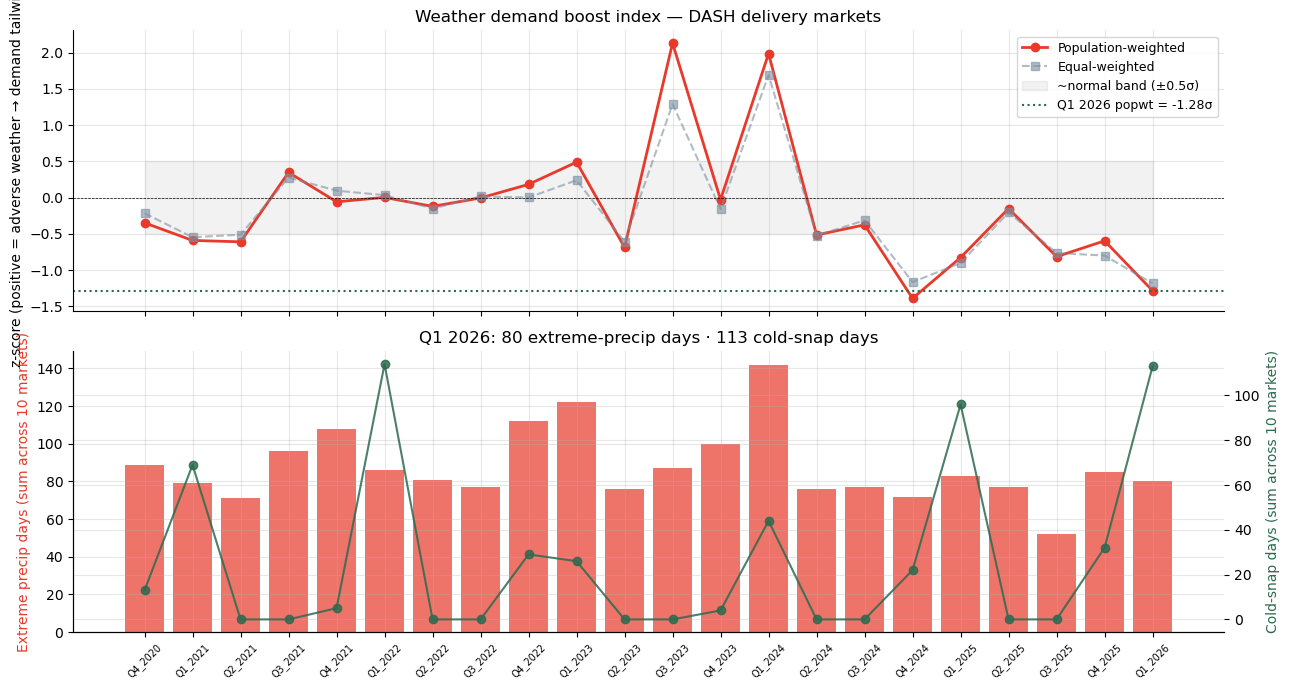

In [2]:
# Time series of weather demand boost index, with Q1 2026 marker
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(master['quarter_label'], master['weather_demand_boost_index_popwt'],
        'o-', lw=2, color=COLORS['dash_primary'], label='Population-weighted')
ax.plot(master['quarter_label'], master['weather_demand_boost_index'],
        's--', alpha=0.6, color=COLORS['consensus'], label='Equal-weighted')
ax.axhline(0, color='black', lw=0.5, ls='--')
ax.fill_between(master['quarter_label'], -0.5, 0.5, alpha=0.10, color='grey',
                 label='~normal band (±0.5σ)')
q1_y = forecast_row['weather_demand_boost_index_popwt']
ax.axhline(q1_y, color=COLORS['actual'], lw=1.5, ls=':',
           label=f'Q1 2026 popwt = {q1_y:+.2f}σ')
ax.set_ylabel('z-score (positive = adverse weather → demand tailwind)')
ax.set_title('Weather demand boost index — DASH delivery markets')
ax.legend(fontsize=9, loc='best')
ax.tick_params(axis='x', rotation=45, labelsize=7)

ax = axes[1]
ax.bar(master['quarter_label'], master['extreme_weather_days_composite'],
       color=COLORS['dash_primary'], alpha=0.7, label='Extreme-precip days')
ax2 = ax.twinx()
ax2.plot(master['quarter_label'], master['cold_snap_days_composite'],
         'o-', color=COLORS['actual'], label='Cold-snap days', alpha=0.85)
ax.set_ylabel('Extreme precip days (sum across 10 markets)', color=COLORS['dash_primary'])
ax2.set_ylabel('Cold-snap days (sum across 10 markets)', color=COLORS['actual'])
ax.set_title(f'Q1 2026: {int(forecast_row["extreme_weather_days_composite"])} extreme-precip days · '
              f'{int(forecast_row["cold_snap_days_composite"])} cold-snap days')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


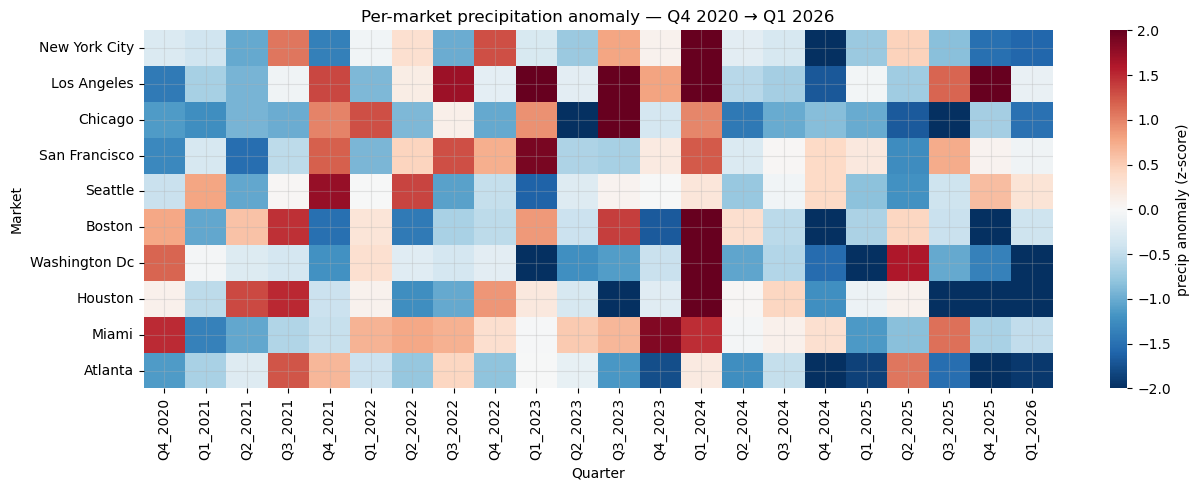

Q1 2026 per-market precipitation anomaly (z-scores):
  New York City       -1.59σ   ↓ mild
  Los Angeles         -0.15σ   normal
  Chicago             -1.49σ   ↓ mild
  San Francisco       -0.09σ   normal
  Seattle             +0.27σ   normal
  Boston              -0.42σ   normal
  Washington Dc       -2.12σ   ↓ mild
  Houston             -3.81σ   ↓ mild
  Miami               -0.50σ   normal
  Atlanta             -1.93σ   ↓ mild


In [3]:
# Per-market precip z-scores for Q1 2026 — heatmap
weather_raw = pd.read_csv(WEATHER_ANOMALY_PATH)
city_cols = [c for c in weather_raw.columns if c.endswith('_precip_anomaly_z')]
display_names = {c: c.replace('_precip_anomaly_z', '').replace('_', ' ').title() for c in city_cols}

# Pivot to (quarter × city) for heatmap
pivot = weather_raw.set_index('quarter_label')[city_cols].rename(columns=display_names)

fig, ax = plt.subplots(figsize=(13, 5))
sns.heatmap(pivot.T, cmap='RdBu_r', center=0,
            cbar_kws={'label': 'precip anomaly (z-score)'},
            vmin=-2, vmax=2,
            annot=False, ax=ax)
ax.set_xlabel('Quarter')
ax.set_ylabel('Market')
ax.set_title('Per-market precipitation anomaly — Q4 2020 → Q1 2026')
plt.tight_layout(); plt.show()

# Q1 2026 city breakdown
q1_w = weather_raw[weather_raw['quarter_label'] == 'Q1_2026'].iloc[0]
print('Q1 2026 per-market precipitation anomaly (z-scores):')
for c in city_cols:
    val = q1_w[c]
    flag = '↑ wet' if val > 0.5 else ('↓ mild' if val < -0.5 else 'normal')
    print(f'  {display_names[c]:18s}  {val:+.2f}σ   {flag}')


## 2. Reddit consumer signal — DASH vs UBER complaint ratios

`reddit_dash_vs_uber_complaint_ratio` = complaint_ratio(r/doordash) /
complaint_ratio(r/UberEats). A value < 1.0 means DASH consumers complain
less than UBER consumers, normalized for posting volume.

**Q1 2026 reading: 0.79** — DASH's complaint ratio is ~21% lower than
UBER's. Sentiment is also marginally positive (+0.07 4-week momentum vs
near-zero baseline).


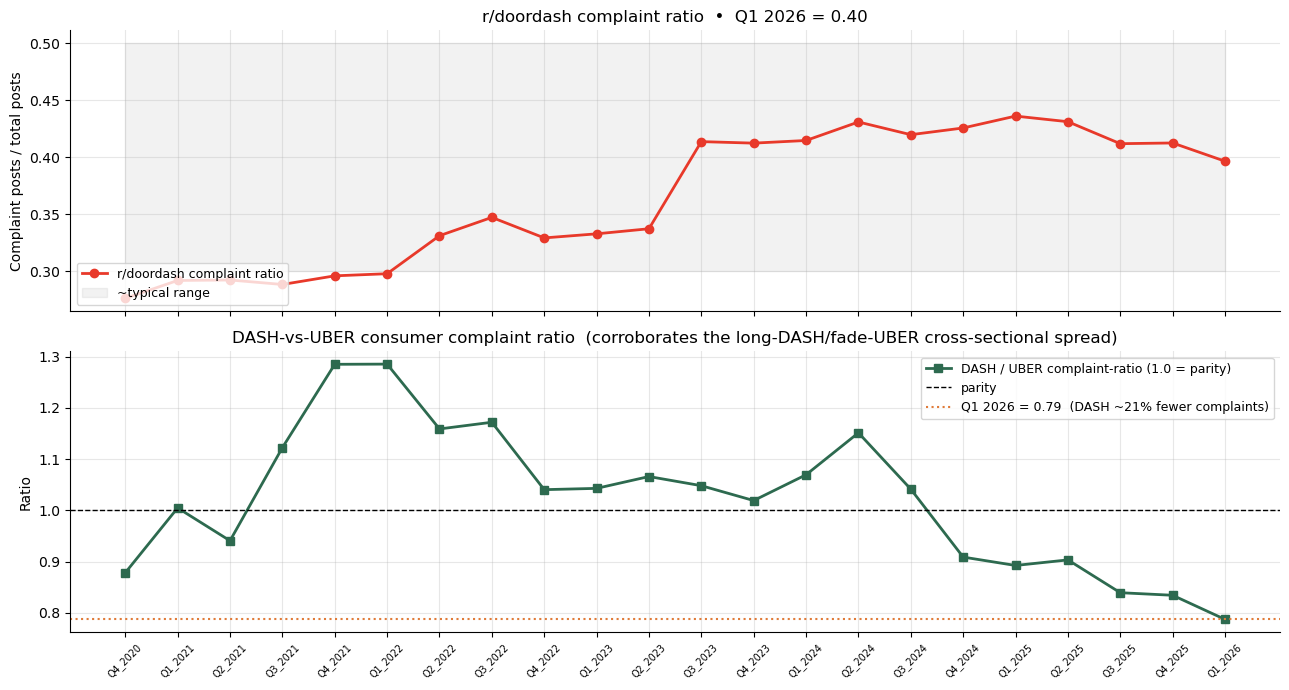

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

# (a) Absolute complaint ratio (DASH only) + DASH-vs-UBER divergence
ax = axes[0]
ax.plot(master['quarter_label'], master['reddit_consumer_complaint_ratio'],
        'o-', lw=2, color=COLORS['dash_primary'],
        label='r/doordash complaint ratio')
ax.fill_between(master['quarter_label'], 0.30, 0.50, alpha=0.10, color='grey',
                 label='~typical range')
ax.set_ylabel('Complaint posts / total posts')
ax.set_title(f'r/doordash complaint ratio  •  Q1 2026 = '
             f'{forecast_row["reddit_consumer_complaint_ratio"]:.2f}')
ax.legend(fontsize=9, loc='lower left')
ax.tick_params(axis='x', rotation=45, labelsize=7)

# (b) DASH-vs-UBER ratio
ax = axes[1]
ax.plot(master['quarter_label'], master['reddit_dash_vs_uber_complaint_ratio'],
        's-', lw=2, color=COLORS['actual'],
        label='DASH / UBER complaint-ratio (1.0 = parity)')
ax.axhline(1.0, color='black', lw=1, ls='--', label='parity')
q1_v = forecast_row['reddit_dash_vs_uber_complaint_ratio']
ax.axhline(q1_v, color=COLORS['forecast'], lw=1.5, ls=':',
           label=f'Q1 2026 = {q1_v:.2f}  (DASH ~{(1-q1_v)*100:.0f}% fewer complaints)')
ax.set_ylabel('Ratio')
ax.set_title('DASH-vs-UBER consumer complaint ratio  (corroborates the long-DASH/fade-UBER cross-sectional spread)')
ax.legend(fontsize=9, loc='best')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


## 3. Reddit supply (driver) signal — operational health

`reddit_supply_stress_index` = fraction of r/doordash_drivers posts flagged
as stress-related (deactivation, pay complaints, app issues). High values
historically preceded EBITDA-margin softness through driver acquisition
costs (per the project spec §4 transmission discussion).

**Q1 2026 reading: 0.063** — within the typical 0.05–0.10 range, no acute
deterioration. Driver pool stable supports the secular contribution-margin
uptrend that anchors the chain's β_C-driven EBITDA story (Session 11).


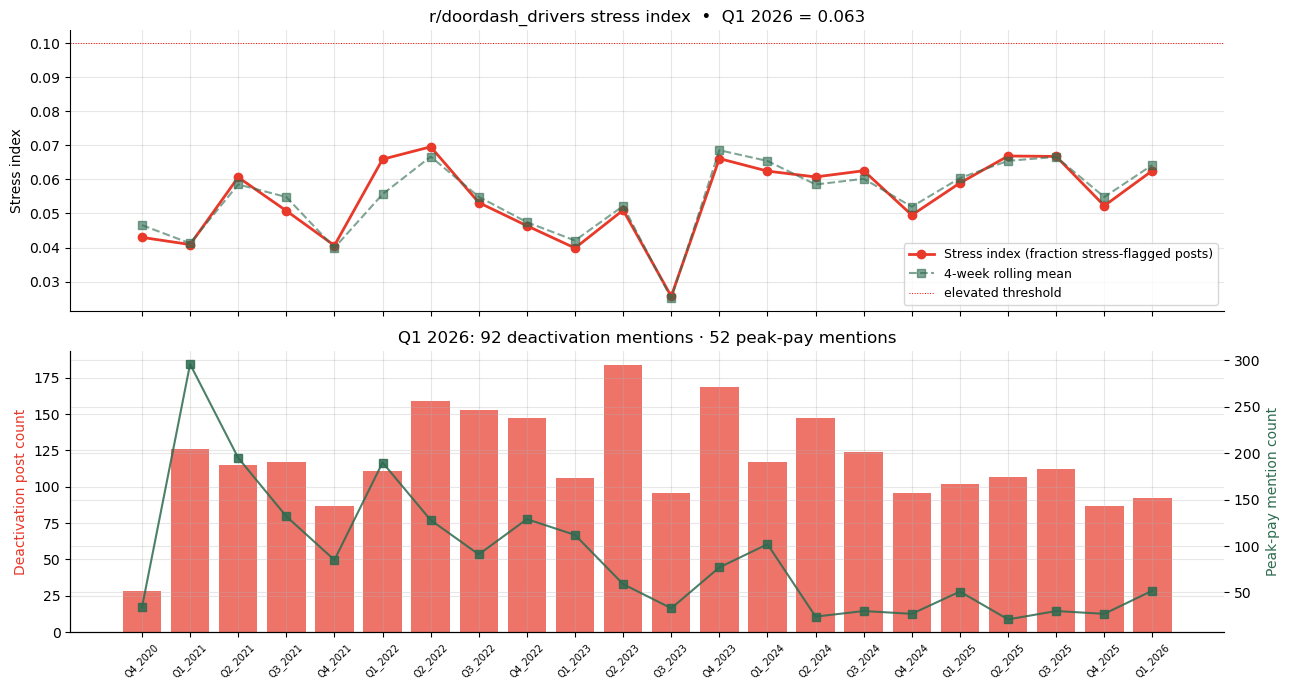

In [5]:
fig, axes = plt.subplots(2, 1, figsize=(13, 7), sharex=True)

ax = axes[0]
ax.plot(master['quarter_label'], master['reddit_supply_stress_index'],
        'o-', lw=2, color=COLORS['dash_primary'],
        label='Stress index (fraction stress-flagged posts)')
ax.plot(master['quarter_label'], master['reddit_driver_supply_stress_4wk'],
        's--', alpha=0.6, color=COLORS['actual'],
        label='4-week rolling mean')
ax.axhline(0.10, color='red', lw=0.7, ls=':', label='elevated threshold')
ax.set_ylabel('Stress index')
ax.set_title(f'r/doordash_drivers stress index  •  '
             f'Q1 2026 = {forecast_row["reddit_supply_stress_index"]:.3f}')
ax.legend(fontsize=9, loc='best')
ax.tick_params(axis='x', rotation=45, labelsize=7)

ax = axes[1]
ax.bar(master['quarter_label'], master['reddit_deactivation_mentions'],
       color=COLORS['dash_primary'], alpha=0.7, label='Deactivation mentions')
ax2 = ax.twinx()
ax2.plot(master['quarter_label'], master['reddit_peak_pay_mentions'],
         's-', color=COLORS['actual'], label='Peak-pay mentions', alpha=0.85)
ax.set_ylabel('Deactivation post count', color=COLORS['dash_primary'])
ax2.set_ylabel('Peak-pay mention count', color=COLORS['actual'])
ax.set_title(f'Q1 2026: {int(forecast_row["reddit_deactivation_mentions"])} deactivation mentions · '
              f'{int(forecast_row["reddit_peak_pay_mentions"])} peak-pay mentions')
ax.tick_params(axis='x', rotation=45, labelsize=7)

plt.tight_layout(); plt.show()


## 4. Jobs snapshot — forward-looking hiring concentration

The jobs panel is a **single forward-looking snapshot** (one scrape date,
2026-05-04), not a time series. Per project spec §7i, it directly supports
the write-up's narrative on (a) DASH's international expansion via Wolt /
Deliveroo, (b) operational investment intensity, and (c) DASH vs UBER
hiring divergence.

The data classifies each open job posting into one or more flag categories:
merchant sales, ops/expansion, dasher supply, international, Deliveroo-market.


In [6]:
# DASH-internal hiring snapshot (one row per flag category, with within-DASH share)
dash_rows = [
    ('Merchant Sales — US',      forecast_row['jobs_dash_merchant_sales_us']),
    ('Merchant Sales — Intl',    forecast_row['jobs_dash_merchant_sales_intl']),
    ('Deliveroo Markets',        forecast_row['jobs_dash_deliveroo_market']),
    ('Ops / Expansion',          forecast_row['jobs_dash_ops_expansion']),
    ('Dasher Supply',            forecast_row['jobs_dash_dasher_supply']),
]
total = sum(v for _, v in dash_rows)
print('=== DASH internal hiring allocation (open postings, 2026-05-04 snapshot) ===')
print(f"{'Category':<28} {'Postings':>10} {'Share':>8}")
print('-' * 50)
for label, v in dash_rows:
    print(f'{label:<28} {int(v):>10d} {v/total*100:>7.0f}%')
print('-' * 50)
print(f"{'TOTAL flagged':<28} {int(total):>10d} {'100%':>8s}")
print()
print('Note: a single posting can hit multiple flag categories (e.g.,')
print('a Berlin Sales Manager counts under Intl Sales AND Deliveroo Markets)')
print('— rows do not sum to 100% strictly. Within-category counts are cleanest.')


=== DASH internal hiring allocation (open postings, 2026-05-04 snapshot) ===
Category                       Postings    Share
--------------------------------------------------
Merchant Sales — US                 199      26%
Merchant Sales — Intl               156      20%
Deliveroo Markets                   113      15%
Ops / Expansion                     248      32%
Dasher Supply                        48       6%
--------------------------------------------------
TOTAL flagged                       764     100%

Note: a single posting can hit multiple flag categories (e.g.,
a Berlin Sales Manager counts under Intl Sales AND Deliveroo Markets)
— rows do not sum to 100% strictly. Within-category counts are cleanest.


**Why we don't show DASH-vs-UBER as raw counts**: the scraper filters UBER
to food-delivery roles only (their Mobility / Freight / ATG segments are
excluded by design — they're not the comparable business). DASH is
food-delivery whole-company. Comparing raw counts (199 DASH vs 67 UBER
on US merchant-sales) conflates DASH's larger food-delivery hiring footprint
with the absence of UBER's other-segment hiring in the dataset. Within-DASH
allocation is the more honest read.


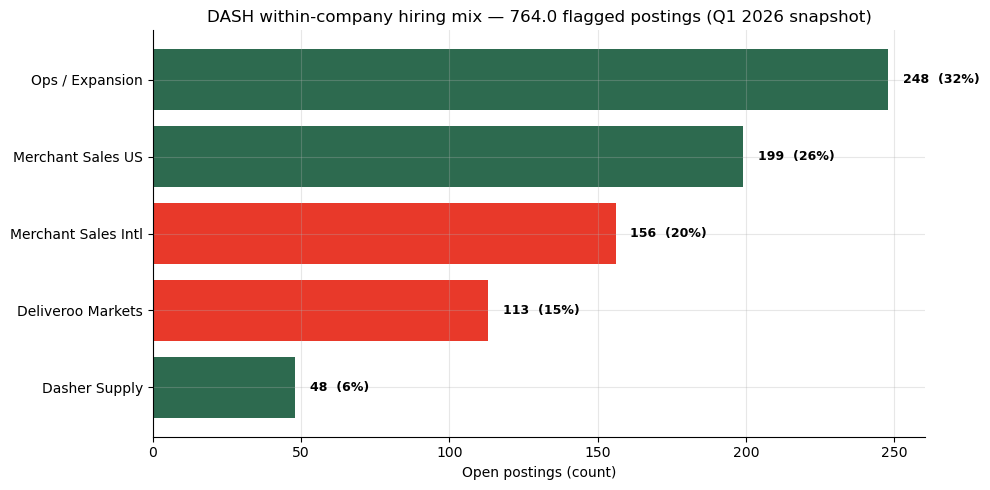

DASH international + Deliveroo share of flagged hiring: 269/764.0 = 35%


In [7]:
# DASH-only category mix — within-company allocation, the honest read
all_dash_cats = [
    ('Merchant Sales US',    forecast_row['jobs_dash_merchant_sales_us']),
    ('Merchant Sales Intl',  forecast_row['jobs_dash_merchant_sales_intl']),
    ('Deliveroo Markets',    forecast_row['jobs_dash_deliveroo_market']),
    ('Ops / Expansion',      forecast_row['jobs_dash_ops_expansion']),
    ('Dasher Supply',        forecast_row['jobs_dash_dasher_supply']),
]
sorted_cats = sorted(all_dash_cats, key=lambda x: x[1])
labels_d = [lbl for lbl, _ in sorted_cats]
vals_d = [v for _, v in sorted_cats]
total_flagged = sum(vals_d)
shares = [v / total_flagged * 100 for v in vals_d]
colors_d = [COLORS['dash_primary'] if 'Intl' in lbl or 'Deliveroo' in lbl
             else COLORS['actual'] for lbl, _ in sorted_cats]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(labels_d, vals_d, color=colors_d)
for i, (v, s) in enumerate(zip(vals_d, shares)):
    ax.text(v + 5, i, f'{int(v)}  ({s:.0f}%)',
            va='center', fontsize=9, fontweight='bold')
ax.set_xlabel('Open postings (count)')
ax.set_title(f'DASH within-company hiring mix — '
             f'{total_flagged} flagged postings (Q1 2026 snapshot)')
plt.tight_layout(); plt.show()

# Within-DASH international share
intl_count = (forecast_row['jobs_dash_merchant_sales_intl']
              + forecast_row['jobs_dash_deliveroo_market'])
intl_share = intl_count / total_flagged * 100
print(f'DASH international + Deliveroo share of flagged hiring: '
       f'{int(intl_count)}/{total_flagged} = {intl_share:.0f}%')


**Reading the jobs panel** (DASH-internal allocation, no UBER comparison):

1. **International intensity**: DASH has 156 merchant-sales roles outside
   the US — 78% as many as the US count (199). 113 of those are in
   Deliveroo markets (UK / DE / FR / AU / etc.). Combined intl + Deliveroo
   roles = ~35% of total flagged hiring. This corroborates the transcripts'
   explicit Deliveroo-integration narrative.
2. **Ops / Expansion at 248 roles** is DASH's single largest hiring
   category — capacity-building investment that supports the secular
   contribution-margin trend behind β_C.
3. **Dasher supply at 48 roles** is small in absolute terms — driver
   acquisition pipeline isn't being aggressively expanded, consistent with
   the Reddit supply-stress reading (§3) showing a stable driver pool.

**On UBER not appearing here**: the pull script filters UBER to food-delivery
postings only (Mobility / Freight / ATG are out of scope). Comparing raw
counts to DASH (which IS food delivery) overstates the gap because the
denominators have different definitions. The right framing is *within* DASH:
how does DASH allocate its hiring? The 35% intl + Deliveroo share is the
internally-meaningful read.


## 5. Synthesis for the L/S note

These corroborating signals shape the **risk and conviction language** in
the recommendation, not the headline magnitude.

| Signal | Q1 2026 reading | Direction | Note |
|---|---|---|---|
| Weather (popwt) | **−1.28σ** mild | **headwind** | Beat call must come from structural strength, NOT weather |
| Reddit consumer DASH/UBER | **0.79** | **bullish DASH** | Corroborates cross-sectional long-DASH/fade-UBER |
| Reddit driver stress | 0.063 | **stable** | Driver pool not stressed → β_C secular trend continues |
| Jobs DASH intl share | **35% of flagged hiring** (156 intl + 113 Deliveroo / 762) | **structural intl push** | Confirms transcripts' Deliveroo integration narrative; not framed vs UBER (segment coverage differs) |

**Updated four-pillar L/S note** (combining model output + this notebook):

> Horizon: 3-6 months · Direction: LONG DASH / fade UBER · Magnitude: SMALL-MEDIUM ·
> Conviction: MEDIUM-HIGH on direction, LOW-MEDIUM on magnitude
>
> Model says DASH beats Q1 2026 GOV consensus by ~+2.3pp (80% CI [+1.35, +3.94]).
> Cross-sectional spread vs UBER strictly positive (+1.59pp, 80% CI [+0.25, +4.83]).
>
> **Corroborated by**: (1) Reddit complaint ratio DASH/UBER = 0.79 — DASH consumers
> 21% less negative than UBER consumers, (2) DASH allocates ~35% of flagged hiring
> to international + Deliveroo markets, confirming the integration narrative,
> (3) driver pool stable (no margin-side shock).
>
> **Beats happen *despite*** a mild Q1 2026 weather quarter (−1.28σ popwt) — the
> structural-strength case is stronger than if weather were neutral or adverse.
>
> **Risks**: standard caveats from prior sessions (n=21 walk-forward, β2 weak,
> Deliveroo accounting in Total GOV) plus this notebook's data quality risk:
> Reddit signal availability declines pre-Q4 2020; jobs is a single snapshot
> not a time series.
